Things that are done in this notebook:

- Adding extra features from external datasets.
- Trimming the price and making log_price
- Finishing up all the features (including time stuff)
- Trying to make it all as functions so it would be easy to reproduce on the test dataset


In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import io
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

<Axes: xlabel='Price (€)', ylabel='Count'>

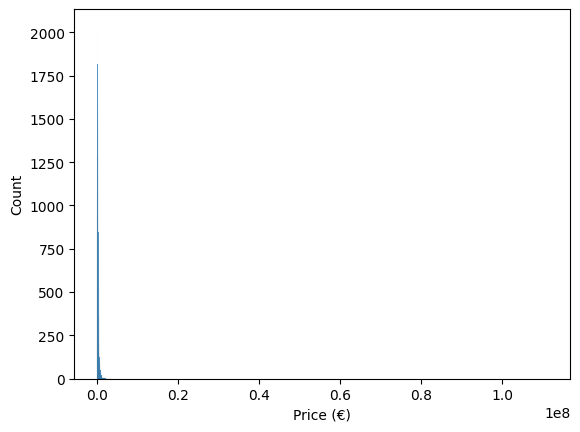

In [2]:
# First i want to visualise the price distribution on the cleaned dataset.
# Then trim the outliers and see how the distribution changes. 
# Just to confirm that the outliers are not skewing the distribution too much. Using logs to visualise the distribution thereafter.
df = pd.read_csv("ppr-group-22312913-train-cleaned.csv")

sns.histplot(data = df, x = "Price (€)", bins = 10000)

<Axes: xlabel='Price (€)', ylabel='Count'>

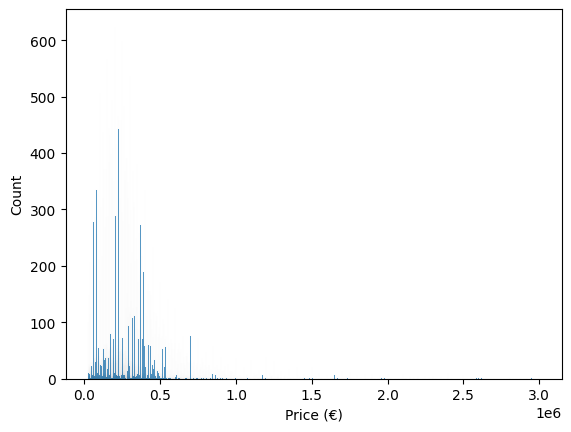

In [3]:
# Clearly a large outliers exists but the main distribution is not skewed by it. We can trim the outliers and see how the distribution changes.

df = df[(df["Price (€)"] >= 25_000) & (df["Price (€)"] <= 3_000_000)]
sns.histplot(data = df, x = "Price (€)", bins = 10000)

In [4]:
# Alltogether, only got about 1% of the data removed by trimming the outliers.
df.shape

(53399, 8)

<Axes: xlabel='log_price', ylabel='Count'>

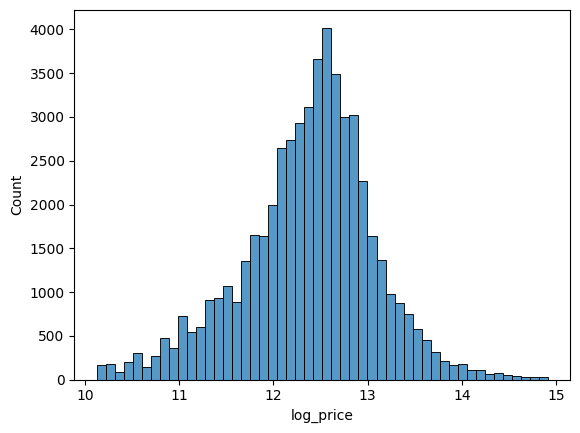

In [5]:
# Now the log_price distribution looks fully simetrical and normal. Even before it was good but values like 100 million euro houses just don't fit.
df["log_price"] = np.log(df["Price (€)"])

sns.histplot(df["log_price"], bins=50)

# Now let's add external dataset by loading and cleaning them up based on the features.

In [6]:
# Add year and month columns to the main dataset
df["Sale (yyyy-mm)"] = pd.to_datetime(df["Sale (yyyy-mm)"])
df["Year"] = df["Sale (yyyy-mm)"].dt.year
df["Month"] = df["Sale (yyyy-mm)"].dt.month
df["Quarter"] = df["Month"].apply(lambda x: (x-1)//3 + 1)

In [7]:
# first load the external datasets
df_income = pd.read_csv("external_datasets/income_and_people_at_work.csv")
df_mortgage = pd.read_csv("external_datasets/mortgage_interest_by_year_month.csv")
df_dwellings = pd.read_csv("external_datasets/new_dwellings_by_area_code.csv")

In [8]:
# Just to see how the income dataset looks like. We will merge it on county and year.
df_income.head(10)

,Statistic Label,Year,County,UNIT,VALUE
0,Index of Disposable Income per Person (excludi...,2016,Co. Carlow,State=100,110.213117
1,Index of Disposable Income per Person (excludi...,2016,Co. Cavan,State=100,98.102443
2,Index of Disposable Income per Person (excludi...,2016,Co. Clare,State=100,97.884387
3,Index of Disposable Income per Person (excludi...,2016,Co. Cork,State=100,106.670816
4,Index of Disposable Income per Person (excludi...,2016,Co. Donegal,State=100,83.739522
5,Index of Disposable Income per Person (excludi...,2016,Co. Dublin,State=100,102.187250
6,Index of Disposable Income per Person (excludi...,2016,Co. Galway,State=100,104.718988
7,Index of Disposable Income per Person (excludi...,2016,Co. Kerry,State=100,100.710942
8,Index of Disposable Income per Person (excludi...,2016,Co. Kildare,State=100,96.583030
9,Index of Disposable Income per Person (excludi...,2016,Co. Kilkenny,State=100,97.382965


In [9]:
df_mortgage.head(10)

,Statistic Label,Month,Selected Sub Indices,UNIT,VALUE
0,Consumer Price Index (Base Dec 2016=100),2016 January,Mortgage Interest,Base Dec 2016=100,103.5
1,Consumer Price Index (Base Dec 2016=100),2016 February,Mortgage Interest,Base Dec 2016=100,103.4
2,Consumer Price Index (Base Dec 2016=100),2016 March,Mortgage Interest,Base Dec 2016=100,102.9
3,Consumer Price Index (Base Dec 2016=100),2016 April,Mortgage Interest,Base Dec 2016=100,102.1
4,Consumer Price Index (Base Dec 2016=100),2016 May,Mortgage Interest,Base Dec 2016=100,101.6
5,Consumer Price Index (Base Dec 2016=100),2016 June,Mortgage Interest,Base Dec 2016=100,101.2
6,Consumer Price Index (Base Dec 2016=100),2016 July,Mortgage Interest,Base Dec 2016=100,100.3
7,Consumer Price Index (Base Dec 2016=100),2016 August,Mortgage Interest,Base Dec 2016=100,100.3
8,Consumer Price Index (Base Dec 2016=100),2016 September,Mortgage Interest,Base Dec 2016=100,99.9
9,Consumer Price Index (Base Dec 2016=100),2016 October,Mortgage Interest,Base Dec 2016=100,100.3


In [10]:
df_dwellings.head(10)

,STATISTIC Label,Quarter,Eircode Output,UNIT,VALUE
0,New Dwelling Completion,2016Q1,A41: Ballyboughal,Number,5
1,New Dwelling Completion,2016Q1,A42: Garristown,Number,1
2,New Dwelling Completion,2016Q1,A45: Oldtown,Number,1
3,New Dwelling Completion,2016Q1,A63: Greystones,Number,19
4,New Dwelling Completion,2016Q1,A67: Wicklow,Number,11
5,New Dwelling Completion,2016Q1,A75: Castleblaney,Number,7
6,New Dwelling Completion,2016Q1,A81: Carrickmacross,Number,2
7,New Dwelling Completion,2016Q1,A82: Kells,Number,19
8,New Dwelling Completion,2016Q1,A83: Enfield,Number,3
9,New Dwelling Completion,2016Q1,A84: Ashbourne,Number,22


In [11]:
# Reuse code from main for the routing.
# Before we will use the merging functions we first will need to clean up counties and area codes in the main dataset.

routing_text = """
A92,Ardee,Louth
Y14,Arklow,Wicklow
A84,Ashbourne,Meath
H65,Athenry,Galway
N37,Athlone,Westmeath
R14,Athy,Kildare
K32,Balbriggan,Dublin
F26,Ballina,Mayo
H53,Ballinasloe,Galway
P31,Ballincollig,Cork
F31,Ballinrobe,Mayo
A75,Ballybay,Monaghan
A41,Ballyboughal,Dublin
F35,Ballyhaunis,Mayo
F56,Ballymote,Sligo
P72,Bandon,Cork
P75,Bantry,Cork
H14,Belturbet,Cavan
R42,Birr,Offaly
A94,Blackrock,Dublin
F52,Boyle,Roscommon
A98,Bray,Wicklow
V23,Caherciveen,Kerry
E21,Cahir,Tipperary
R93,Carlow,Carlow
A81,Carrickmacross,Monaghan
N41,Carrick-on-Shannon,Leitrim
E32,Carrick-on-Suir,Tipperary
P43,Carrigaline,Cork
E25,Cashel,Tipperary
F23,Castlebar,Mayo
A75,Castleblaney,Monaghan
F45,Castlerea,Roscommon
H12,Cavan,Cavan
P56,Charleville,Cork
F12,Claremorris,Mayo
H71,Clifden,Galway
P85,Clonakilty,Cork
H23,Clones,Monaghan
E91,Clonmel,Tipperary
P24,Cobh,Cork
H16,Cootehill,Cavan
T12,Cork (centre and southside),Cork
T23,Cork (northside),Cork
P14,Crookstown,Cork
P32,Donoughmore,Cork
P47,Dunmanway,Cork
T56,Watergrasshill,Cork
T34,Whitechurch,Cork
R56,Curragh Camp,Kildare
A63,Delgany,Wicklow
F94,Donegal,Donegal
A92,Drogheda,Louth
D01,Dublin 1,Dublin
D02,Dublin 2,Dublin
D03,Dublin 3,Dublin
D04,Dublin 4,Dublin
D05,Dublin 5,Dublin
D06,Dublin 6,Dublin
D6W,Dublin 6W,Dublin
D07,Dublin 7,Dublin
D08,Dublin 8,Dublin
D09,Dublin 9,Dublin
D10,Dublin 10,Dublin
D11,Dublin 11,Dublin
D12,Dublin 12,Dublin
D13,Dublin 13,Dublin
D14,Dublin 14,Dublin
D15,Dublin 15,Dublin
D16,Dublin 16,Dublin
D17,Dublin 17,Dublin
D18,Dublin 18,Dublin
D20,Dublin 20,Dublin
D22,Dublin 22,Dublin
D24,Dublin 24,Dublin
A86,Dunboyne,Meath
A91,Dundalk,Louth
X35,Dungarvan,Waterford
A85,Dunshaughlin,Meath
R45,Edenderry,Offaly
A83,Enfield,Meath
V95,Ennis,Clare
Y21,Enniscorthy,Wexford
P61,Fermoy,Cork
H91,Galway,Galway
A42,Garristown,Dublin
A96,Glenageary,Dublin
Y25,Gorey,Wexford
A63,Greystones,Wicklow
A82,Kells,Meath
A63,Kilcoole,Wicklow
R51,Kildare,Kildare
R95,Kilkenny,Kilkenny
V93,Killarney,Kerry
X42,Kilmacthomas,Waterford
V35,Kilmallock,Limerick
V15,Kilrush,Clare
A82,Kingscourt,Cavan
P17,Kinsale,Cork
A92,Laytown-Bettystown-Mornington,Meath
F92,Letterkenny,Donegal
F93,Lifford,Donegal
V94,Limerick,Limerick
V31,Listowel,Kerry
T45,Little Island,Cork
N39,Longford,Longford
H62,Loughrea,Galway
K78,Lucan,Dublin
K45,Lusk,Dublin
P12,Macroom,Cork
K36,Malahide,Dublin
P51,Mallow,Cork
W23,Maynooth,Kildare
P25,Midleton,Cork
P67,Mitchelstown,Cork
H18,Monaghan,Monaghan
W34,Monasterevin,Kildare
A94,Monkstown,Dublin
R21,Muine Bheag,Carlow
N91,Mullingar,Westmeath
W91,Naas,Kildare
C15,Navan,Meath
E45,Nenagh,Tipperary
Y34,New Ross,Wexford
W12,Newbridge,Kildare
A63,Newcastle,Wicklow
V42,Newcastle West,Limerick
A63,Newtownmountkennedy,Wicklow
A45,Portlaoise,Laois
A67,Rathnew,Wicklow
A85,Ratoath,Meath
F42,Roscommon,Roscommon
E53,Roscrea,Tipperary
K56,Rush,Dublin
V14,Shannon,Clare
K34,Skerries,Dublin
P81,Skibbereen,Cork
F91,Sligo,Sligo
A83,Summerhill,Meath
K67,Swords,Dublin
E41,Thurles,Tipperary
E34,Tipperary,Tipperary
V92,Tralee,Kerry
H54,Tuam,Galway
R32,Portlaoise,Laois
R35,Tullamore,Offaly
A82,Virginia,Cavan
X91,Waterford,Waterford
F28,Westport,Mayo
Y35,Wexford,Wexford
A67,Wicklow,Wicklow
P36,Youghal,Cork
"""

routing_df = pd.read_csv(
    io.StringIO(routing_text),
    sep=',',
    header=None,
    names=['Eircode3', 'Town', 'County'],
)


# Perfect we have 152 different town names and 139 difference area codes.
print('Routing reference rows:', routing_df["Eircode3"].shape)
print('Unique area codes in routing reference:', routing_df["Eircode3"].nunique())


Routing reference rows: (152,)
Unique area codes in routing reference: 139


In [12]:
# As we saw the main dataset has 152 unique codes, while there is only 139, but we also include "Unknown" so it should be 140.
# However we have 2 area codes that are assigned to difference counties.

area_county = (
    routing_df[["Eircode3", "County"]]   # keep only these two
    .dropna()                            # remove rows with NaN in either
    .drop_duplicates()                   # remove duplicates
)

area_county["Eircode3"].value_counts().loc[lambda x: x > 1]

Eircode3
A92    2
A82    2
Name: count, dtype: int64

In [13]:
# Meaning we will asiign A92 to Louth. 
df[df["Area Code"] == "A92"]["County"].value_counts()

County
Louth     597
Meath     110
Dublin      1
Name: count, dtype: int64

In [14]:
# And A82 to Cavan.
df[df["Area Code"] == "A82"]["County"].value_counts()

County
Cavan      195
Meath      145
Clare        1
Kildare      1
Carlow       1
Name: count, dtype: int64

In [15]:
area_county = area_county[~((area_county["Eircode3"] == "A82") & (area_county["County"] != "Cavan"))]
area_county = area_county[~((area_county["Eircode3"] == "A92") & (area_county["County"] != "Louth"))]

area_county.shape

(139, 2)

In [16]:
# This shows us there in our original dataset there are issues, people have been putting difference routing codes with differenct addresses, which is an issue.
# However, we don't really know which one is correct, (county vs routing code).
# So, instead we will merge the official county from the routing code dataset.
duplicates = (
    df.groupby("Area Code")["County"]
    .nunique()
    .sort_values(ascending=False)
)

duplicates[duplicates == 1].sum()

np.int64(89)

In [17]:
# We will now need to clean wrong area codes, that aren't in the routing dataset, as they are most likely are mistakes. 
# Secondly we will need to create cleaned county feature, because people have been putting wrong county names, for different area codes.

valid_area_codes = set(
    routing_df["Eircode3"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

valid_area_codes.add("Unknown")

invalid_rows = df[~df["Area Code"].isin(valid_area_codes)]

print("Invalid rows:", len(invalid_rows))
print("Invalid unique area codes:", invalid_rows["Area Code"].nunique())
print(invalid_rows["Area Code"].value_counts().head(20))

Invalid rows: 14
Invalid unique area codes: 14
Area Code
P23    1
A65    1
V34    1
P52    1
C95    1
N42    1
Y43    1
E28    1
P62    1
R96    1
W19    1
X34    1
E24    1
W53    1
Name: count, dtype: int64


In [18]:
# Now let's go into main dataset and change those invalid area codes to "Unknown".DS_Store
df["Area Code"] = df["Area Code"].where(
    df["Area Code"].isin(valid_area_codes),
    "Unknown"
)

In [19]:
area_county.shape

(139, 2)

In [20]:
# Just an example to show that this area code could have more than one county assigned to it, so we will create a clean county on routing_df.
df[df["Area Code"] == "R93"]

,row_id,Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,Is_Second_Hand,log_price,Year,Month,Quarter
30230,30237,2021-12-01,56 ASHFIELD BLACKROCK RD CARLOW,Carlow,R93,230000.0,No,1,12.345835,2021,12,4
30340,30347,2021-06-01,25 CLUAIN RIADA LINK RD BROWNS HILL CARLOW,Carlow,R93,216000.0,No,1,12.283034,2021,6,2
30384,30391,2021-08-01,99 TANNER HALL ATHY RD CARLOW,Carlow,R93,101150.0,Yes,0,11.524360,2021,8,3
30487,30494,2021-12-01,JERUSALEM CARLOW KILDARE,Kildare,R93,250000.0,No,1,12.429216,2021,12,4
30523,30530,2021-08-01,4 AVONDALE DR HANOVER CARLOW,Carlow,R93,195000.0,No,1,12.180755,2021,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...
53181,53190,2024-11-01,SPRINGHILL LAOIS,Laois,R93,515000.0,No,1,13.151922,2024,11,4
53195,53204,2024-04-01,35 MILLENIUM COURT TULLOW RD CARLOW,Carlow,R93,272000.0,No,1,12.513557,2024,4,2
53270,53279,2024-01-01,124 SAND HILLS HACKETSTOWN RD CARLOW,Carlow,R93,275000.0,No,1,12.524526,2024,1,1
53570,53579,2024-02-01,9 GRAIGOWAN TULLOW CARLOW,Carlow,R93,140000.0,No,1,11.849398,2024,2,1


In [21]:
# Now we will merge the official county from the routing dataset, and create a new feature "County_Clean" in the main dataset.
df = df.merge(
    area_county[["Eircode3", "County"]].rename(columns={"Eircode3": "Area Code", "County": "County_Area"}),
    on="Area Code",
    how="left"
)

# Then we will fill the missing values in the "County_Clean" column with the original "County" column, as for some area codes we don't have a clean county, and it is better to have some county than no county at all.
df["County_Clean"] = df["County_Area"].fillna(df["County"])

In [22]:
# So we had around 2237 values that were different between the original county and the one we got from the routing code, which is around 1% of the data, so not a huge deal but it is good to have it cleaned up.
(df["County"] != df["County_Clean"]).sum()

np.int64(905)

In [23]:
df.shape

(53399, 14)

In [24]:
df.head(10)

,row_id,Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,Is_Second_Hand,log_price,Year,Month,Quarter,County_Area,County_Clean
0,1,2016-04-01,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,450000.00,No,1,13.017003,2016,4,2,NaN,Wicklow
1,2,2016-09-01,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,560000.00,No,1,13.235692,2016,9,3,Dublin,Dublin
2,3,2016-12-01,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,44200.00,No,1,10.696480,2016,12,4,NaN,Tipperary
3,4,2016-08-01,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,65000.00,No,1,11.082143,2016,8,3,NaN,Leitrim
4,5,2016-04-01,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,400000.00,No,1,12.899220,2016,4,2,NaN,Louth
5,6,2016-07-01,SILVERDALE HOUSE CASTLEKNOCK RD DUBLIN,Dublin,Unknown,1320000.00,No,1,14.093142,2016,7,3,NaN,Dublin
6,7,2016-02-01,11 CLUAIN CREGG CARRICK ON SUIR TIPPERARY,Tipperary,E32,235000.00,No,1,12.367341,2016,2,1,Tipperary,Tipperary
7,8,2016-11-01,1 HAZELDEAN BLACKWATER ENNISCORTHY,Wexford,Y21,189185.02,No,0,12.150481,2016,11,4,Wexford,Wexford
8,9,2016-06-01,4 WATERSIDE CASTLEHEIGHTS KILMONEY RD,Cork,Unknown,226000.00,No,1,12.328290,2016,6,2,NaN,Cork
9,10,2016-12-01,56 WESTON MEADOW LUCAN DUBLIN,Dublin,K78,490000.00,No,1,13.102161,2016,12,4,Dublin,Dublin


In [25]:
# Here we will need to merge on the area code, we will get first 3 letters, and merge on that. But check there they are the same as in our dataset.
# We then need to also keep track per county and keep track of the number of new dwellings built in the area.
# Also it is done by quarters, so we will need to do something like [1,2,3] -> 1 etc.

# First i will try a few things and then actually merge it. Quater is in the numeric format.
def merge_dwellings(df, routing_df):
    df_dwellings = pd.read_csv("external_datasets/new_dwellings_by_area_code.csv")

    # Clean keys
    df_dwellings["Area Code"] = df_dwellings["Eircode Output"].str[:3]
    df_dwellings["Quarter"] = df_dwellings["Quarter"].str.replace("Q", " ", regex=False)
    df_dwellings["Year"] = df_dwellings["Quarter"].str.split(" ").str[0].astype(int)
    df_dwellings["Quarter"] = df_dwellings["Quarter"].str.split(" ").str[1].astype(int)

    # Area-level table: one row per area/year/quarter
    area_dwellings = (
        df_dwellings[["Area Code", "Year", "Quarter", "VALUE"]]
        .rename(columns={"VALUE": "Area_New_Dwellings"})
    )

    # Attach clean county to each area code
    area_dwellings = area_dwellings.merge(
        routing_df[["Eircode3", "County"]].rename(
            columns={"Eircode3": "Area Code", "County": "County_Clean"}
        ),
        on="Area Code",
        how="left"
    )

    # County-level table: collapse to one row per county/year/quarter
    county_dwellings = (
        area_dwellings.groupby(["County_Clean", "Year", "Quarter"], as_index=False)["Area_New_Dwellings"]
        .sum()
        .rename(columns={"Area_New_Dwellings": "County_New_Dwellings"})
    ) # type: ignore

    # Merge county-level feature
    df = df.merge(
        county_dwellings,
        on=["County_Clean", "Year", "Quarter"],
        how="left"
    )

    # Merge area-level feature
    df = df.merge(
        area_dwellings[["Area Code", "Year", "Quarter", "Area_New_Dwellings"]],
        on=["Area Code", "Year", "Quarter"],
        how="left"
    )

    return df


In [26]:
# First inspect all the datasets and see what featrues we can merge on and what features we can extract from the external datasets.
# However, here under statistic label we have 3 different features, and we want to merge all of them.
# This is easy clean up County to just get rid of Co. and merge on year and county.

# For easy to merge it for the test. 
# We only need to bring one feature VALUE and in the main data set name it "Index of Disposable income per Person (Excluding Rent)" name it on the Statistic Lable.
def merge_income(df):
    df_income = pd.read_csv("external_datasets/income_and_people_at_work.csv")
    df_income["County"] = df_income["County"].str.replace("Co. ", "")

    # we will need to create a label for each of the 3 features, and then merge them separately.
    label_map = {
        "Index of Disposable Income per Person (excluding Rent)": "Income_Disposable_Index",
        "Persons at Work": "Persons_At_Work",
        "Percentage of Persons at Work": "Pct_Persons_At_Work",
    }

    df_income["Statistic Label"] = df_income["Statistic Label"].map(label_map)

    df_income = (
        df_income[["County", "Year", "Statistic Label", "VALUE"]]
        .pivot_table(
            index=["County", "Year"],
            columns="Statistic Label",
            values="VALUE",
            aggfunc="first",
        )
        .reset_index()
        .rename(columns={"County": "County_Clean"})
    )

    df = df.merge(df_income, on=["County_Clean", "Year"], how="left")
    return df

In [27]:
# Easy clean up month and year because it is in the format "2016 January" etc, and merge on those features for the whole dataset.
def merge_mortgage(df):    
    df_mortgage = pd.read_csv("external_datasets/mortgage_interest_by_year_month.csv")
    df_mortgage["Year"] = df_mortgage["Month"].str.split(" ").str[0].astype(int)
    df_mortgage["Month"] = df_mortgage["Month"].str.split(" ").str[1]
    month_mapping = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
                     "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}
    df_mortgage["Month"] = df_mortgage["Month"].map(month_mapping)
    df_mortgage = df_mortgage[["Year", "Month", "VALUE"]]
    df_mortgage = df_mortgage.rename(columns={"VALUE": "Mortgage Interest Rate"})
    df = df.merge(df_mortgage, on=["Year", "Month"], how="left")
    return df

In [28]:
def merge_population(df):
    df_population = pd.read_csv("external_datasets/population.csv")
    df_population["County"] = df_population["County"].str.replace("Co. ", "")
    df_population = df_population.rename(columns={"County": "County_Clean", "Year": "Year", "VALUE": "Population"})
    df = df.merge(df_population[["County_Clean", "Year", "Population"]], on=["County_Clean", "Year"], how="left")
    return df

In [29]:
df = merge_dwellings(df, area_county)
df = merge_income(df)
df = merge_mortgage(df)
df = merge_population(df)

In [30]:
# As we can see we have successfully merged all the features, and we have some missing values but that is expected as not all areas have data for all features.
df.shape

(53399, 21)

In [31]:
df.head(10)

,row_id,Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,Is_Second_Hand,log_price,Year,...,Quarter,County_Area,County_Clean,County_New_Dwellings,Area_New_Dwellings,Income_Disposable_Index,Pct_Persons_At_Work,Persons_At_Work,Mortgage Interest Rate,Population
0,1,2016-04-01,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,450000.00,No,1,13.017003,2016,...,2,NaN,Wicklow,74,NaN,96.737377,2.914414,62.117293,102.1,NaN
1,2,2016-09-01,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,560000.00,No,1,13.235692,2016,...,3,Dublin,Dublin,841,62.0,102.187250,35.123287,748.611481,99.9,NaN
2,3,2016-12-01,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,44200.00,No,1,10.696480,2016,...,4,NaN,Tipperary,43,NaN,112.948594,2.859716,60.951470,100.0,NaN
3,4,2016-08-01,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,65000.00,No,1,11.082143,2016,...,3,NaN,Leitrim,11,NaN,98.348678,0.730959,15.579537,100.3,NaN
4,5,2016-04-01,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,400000.00,No,1,12.899220,2016,...,2,NaN,Louth,108,NaN,90.806879,2.019839,43.050479,102.1,NaN
5,6,2016-07-01,SILVERDALE HOUSE CASTLEKNOCK RD DUBLIN,Dublin,Unknown,1320000.00,No,1,14.093142,2016,...,3,NaN,Dublin,841,NaN,102.187250,35.123287,748.611481,100.3,NaN
6,7,2016-02-01,11 CLUAIN CREGG CARRICK ON SUIR TIPPERARY,Tipperary,E32,235000.00,No,1,12.367341,2016,...,1,Tipperary,Tipperary,33,2.0,112.948594,2.859716,60.951470,103.4,NaN
7,8,2016-11-01,1 HAZELDEAN BLACKWATER ENNISCORTHY,Wexford,Y21,189185.02,No,0,12.150481,2016,...,4,Wexford,Wexford,69,22.0,100.829814,2.218727,47.289563,99.9,NaN
8,9,2016-06-01,4 WATERSIDE CASTLEHEIGHTS KILMONEY RD,Cork,Unknown,226000.00,No,1,12.328290,2016,...,2,NaN,Cork,237,NaN,106.670816,12.148549,258.932015,101.2,NaN
9,10,2016-12-01,56 WESTON MEADOW LUCAN DUBLIN,Dublin,K78,490000.00,No,1,13.102161,2016,...,4,Dublin,Dublin,1100,23.0,102.187250,35.123287,748.611481,100.0,NaN


In [32]:
# Now to finish up we are adding last two features, area_trailing_12m_median_log_price and month_index, which we will need for the final model.
# 1) Month index
df = df.copy()
df["Sale (yyyy-mm)"] = pd.to_datetime(df["Sale (yyyy-mm)"], format="%Y-%m", errors="coerce")
df["sale_period"] = df["Sale (yyyy-mm)"].dt.to_period("M")

origin_period = df["sale_period"].min()
df["month_index"] = (
    (df["sale_period"].dt.year - origin_period.year) * 12
    + (df["sale_period"].dt.month - origin_period.month)
)

# 2) Helper to create trailing 12-month median log-price features
def complete_group_month_grid(monthly_df, group_col, period_col="sale_period", end_period=None):
    if monthly_df.empty:
        return monthly_df.copy()

    start_period = monthly_df[period_col].min()
    final_period = end_period if end_period is not None else monthly_df[period_col].max()
    full_periods = pd.period_range(start_period, final_period, freq="M")

    frames = []
    for group_value, group_df in monthly_df.groupby(group_col):
        expanded = group_df.set_index(period_col).reindex(full_periods)
        expanded[group_col] = group_value
        expanded.index.name = period_col
        frames.append(expanded.reset_index())

    return pd.concat(frames, ignore_index=True)


def add_trailing_12m_median(df, group_col, feature_name, exclude_unknown=False):
    base_df = df.copy()

    ref = base_df[[group_col, "sale_period", "log_price"]].dropna().copy()
    if exclude_unknown:
        ref = ref[ref[group_col] != "Unknown"]

    monthly = (
        ref.groupby([group_col, "sale_period"])["log_price"]
        .median()
        .rename("monthly_group_median_log_price")
        .reset_index()
    )

    expanded = complete_group_month_grid(monthly, group_col=group_col, end_period=base_df["sale_period"].max())

    expanded[feature_name] = (
        expanded.groupby(group_col)["monthly_group_median_log_price"]
        .transform(lambda s: s.shift(1).rolling(12, min_periods=6).median())
    )

    base_df = base_df.merge(
        expanded[[group_col, "sale_period", feature_name]],
        on=[group_col, "sale_period"],
        how="left",
    )

    if exclude_unknown:
        base_df.loc[base_df[group_col] == "Unknown", feature_name] = np.nan

    return base_df

# 3) Create the two features you want
df = add_trailing_12m_median(
    df,
    group_col="County_Clean",
    feature_name="county_trailing_12m_median_log_price",
    exclude_unknown=False,
)

df = add_trailing_12m_median(
    df,
    group_col="Area Code",
    feature_name="area_trailing_12m_median_log_price",
    exclude_unknown=True,
)

print(df[[
    "month_index",
    "county_trailing_12m_median_log_price",
    "area_trailing_12m_median_log_price"
]].head())

print((df[[
    "county_trailing_12m_median_log_price",
    "area_trailing_12m_median_log_price"
]].isna().mean() * 100).round(2))

   month_index  county_trailing_12m_median_log_price  \
0            3                                   NaN   
1            8                             12.590239   
2           11                             11.597797   
3            7                             11.350407   
4            3                                   NaN   

   area_trailing_12m_median_log_price  
0                                 NaN  
1                           13.239662  
2                                 NaN  
3                                 NaN  
4                                 NaN  
county_trailing_12m_median_log_price     4.78
area_trailing_12m_median_log_price      38.50
dtype: float64


In [33]:
# Here we are going to create a new feature that will give us the size km² per routing key.
gdf = gpd.read_file("external_datasets/routingkeys_shape_itm_2016_09_29/RoutingKeys_ITM_region.shp")

gdf["area_km2"] = gdf.geometry.area / 1e6

gdf = gdf.rename(columns={"RoutingKey": "Area Code"})

# Then we merge it onto the main dataset.
df = df.merge(
    gdf[["Area Code", "area_km2"]],
    on="Area Code",
    how="left"
)

In [34]:
# Now we are going to merge the size of county from Wikipidia.

county_size_text = """
Cork,7508
Galway,6151
Mayo,5588
Donegal,4860
Kerry,4807
Tipperary,4305
Clare,3450
Limerick,2756
Roscommon,2548
Wexford,2367
Meath,2342
Kilkenny,2073
Wicklow,2027
Offaly,2001
Cavan,1932
Waterford,1858
Westmeath,1840
Sligo,1838
Laois,1720
Kildare,1695
Leitrim,1589
Monaghan,1295
Longford,1091
Dublin,922
Carlow,897
Louth,826
"""

county_size_df = pd.read_csv(
    io.StringIO(county_size_text),
    sep=',',
    header=None,
    names=['County_Clean', 'County_km2'],
)

county_size_df.shape

(26, 2)

In [35]:
# Time to merge it onto the main dataset, we will need to clean up county names in the main dataset, and then merge on that.

df = df.merge(
    county_size_df,
    on="County_Clean",
    how="left"
)

In [36]:
# creating a few new features here.
df["Dwellings_Built_Area"] = df["Area_New_Dwellings"] / df["area_km2"]
df["Dwellings_Built_County"] = df["County_New_Dwellings"] / df["County_km2"]
df["Persons_Work_County"] = (df["Persons_At_Work"] * 1000) / df["County_km2"] 
df["Population_County"] = df["Population"] / df["County_km2"]

In [37]:
df.head(10)

,row_id,Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,Is_Second_Hand,log_price,Year,...,sale_period,month_index,county_trailing_12m_median_log_price,area_trailing_12m_median_log_price,area_km2,County_km2,Dwellings_Built_Area,Dwellings_Built_County,Persons_Work_County,Population_County
0,1,2016-04-01,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,450000.00,No,1,13.017003,2016,...,2016-04,3,NaN,NaN,NaN,2027,NaN,0.036507,30.644940,NaN
1,2,2016-09-01,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,560000.00,No,1,13.235692,2016,...,2016-09,8,12.590239,13.239662,13.732642,922,4.514790,0.912148,811.943038,NaN
2,3,2016-12-01,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,44200.00,No,1,10.696480,2016,...,2016-12,11,11.597797,NaN,NaN,4305,NaN,0.009988,14.158297,NaN
3,4,2016-08-01,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,65000.00,No,1,11.082143,2016,...,2016-08,7,11.350407,NaN,NaN,1589,NaN,0.006923,9.804617,NaN
4,5,2016-04-01,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,400000.00,No,1,12.899220,2016,...,2016-04,3,NaN,NaN,NaN,826,NaN,0.130751,52.119224,NaN
5,6,2016-07-01,SILVERDALE HOUSE CASTLEKNOCK RD DUBLIN,Dublin,Unknown,1320000.00,No,1,14.093142,2016,...,2016-07,6,12.575007,NaN,NaN,922,NaN,0.912148,811.943038,NaN
6,7,2016-02-01,11 CLUAIN CREGG CARRICK ON SUIR TIPPERARY,Tipperary,E32,235000.00,No,1,12.367341,2016,...,2016-02,1,NaN,NaN,337.462503,4305,0.005927,0.007666,14.158297,NaN
7,8,2016-11-01,1 HAZELDEAN BLACKWATER ENNISCORTHY,Wexford,Y21,189185.02,No,0,12.150481,2016,...,2016-11,10,11.876285,11.673061,1056.193601,2367,0.020830,0.029151,19.978691,NaN
8,9,2016-06-01,4 WATERSIDE CASTLEHEIGHTS KILMONEY RD,Cork,Unknown,226000.00,No,1,12.328290,2016,...,2016-06,5,NaN,NaN,NaN,7508,NaN,0.031566,34.487482,NaN
9,10,2016-12-01,56 WESTON MEADOW LUCAN DUBLIN,Dublin,K78,490000.00,No,1,13.102161,2016,...,2016-12,11,12.613202,12.495004,25.304082,922,0.908944,1.193059,811.943038,NaN


In [38]:
df.shape

(53399, 31)

In [40]:
# Keep the cleaner county column if you have it
county_col = "County_Clean" if "County_Clean" in df.columns else "County"

candidate_num = [
    "month_index",
    "Year",
    "County_km2",
    "Month",
    "Pct_Persons_At_Work",
    "Is_Second_Hand",
    "County_New_Dwellings",
    "Area_New_Dwellings",
    "Income_Disposable_Index",
    "Persons_At_Work",
    "Mortgage Interest Rate",
    "Population",
    "Dwellings_Built_Area",
    "Dwellings_Built_County",
    "Persons_Work_County",
    "Population_County",
    "county_trailing_12m_median_log_price",
    "area_trailing_12m_median_log_price",
]

candidate_cat = [
    county_col,
    "Area Code",
    "Not Full Market Price",
]

num_features = [col for col in candidate_num if col in df.columns]
cat_features = [col for col in candidate_cat if col in df.columns]
feature_cols = num_features + cat_features

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

model_df = df[feature_cols + ["log_price", "Sale (yyyy-mm)"]].copy()
model_df["sale_period"] = pd.to_datetime(model_df["Sale (yyyy-mm)"]).dt.to_period("M")
model_df = model_df.dropna(subset=["log_price", "sale_period"]).copy()

# Last 12 months for validation
all_periods = sorted(model_df["sale_period"].dropna().unique())
val_periods = all_periods[-12:]

train_mask = ~model_df["sale_period"].isin(val_periods)
val_mask = model_df["sale_period"].isin(val_periods)

X_train = model_df.loc[train_mask, feature_cols].copy()
X_val = model_df.loc[val_mask, feature_cols].copy()
y_train = model_df.loc[train_mask, "log_price"]
y_val = model_df.loc[val_mask, "log_price"]

# CatBoost wants categorical columns as strings
for col in cat_features:
    X_train[col] = X_train[col].astype("string").fillna("Missing")
    X_val[col] = X_val[col].astype("string").fillna("Missing")

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=100,
)

pred_val = model.predict(X_val)

rmse_log = np.sqrt(np.mean((y_val - pred_val) ** 2))
mae_log = np.mean(np.abs(y_val - pred_val))
mae_euro = np.mean(np.abs(np.exp(y_val) - np.exp(pred_val)))
r2 = r2_score(y_val, pred_val)

print("Validation months:", val_periods[0], "to", val_periods[-1])
print("RMSE log:", rmse_log)
print("MAE log :", mae_log)
print("MAE euro:", mae_euro)
print("R squared:", r2)

importance = (
    pd.Series(model.get_feature_importance(), index=feature_cols)
    .sort_values(ascending=False)
    .to_frame("importance")
)
display(importance.head(20))


Numeric features: ['month_index', 'Year', 'County_km2', 'Month', 'Pct_Persons_At_Work', 'Is_Second_Hand', 'County_New_Dwellings', 'Area_New_Dwellings', 'Income_Disposable_Index', 'Persons_At_Work', 'Mortgage Interest Rate', 'Population', 'Dwellings_Built_Area', 'Dwellings_Built_County', 'Persons_Work_County', 'Population_County', 'county_trailing_12m_median_log_price', 'area_trailing_12m_median_log_price']
Categorical features: ['County_Clean', 'Area Code', 'Not Full Market Price']
0:	learn: 0.6953473	test: 0.6924344	best: 0.6924344 (0)	total: 15.8ms	remaining: 15.8s
100:	learn: 0.5215516	test: 0.4918397	best: 0.4918397 (100)	total: 670ms	remaining: 5.96s
200:	learn: 0.5172162	test: 0.4893314	best: 0.4893314 (200)	total: 1.19s	remaining: 4.72s
300:	learn: 0.5142432	test: 0.4890766	best: 0.4889599 (258)	total: 1.71s	remaining: 3.97s
400:	learn: 0.5117167	test: 0.4890791	best: 0.4888843 (337)	total: 2.27s	remaining: 3.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 

,importance
area_trailing_12m_median_log_price,19.585693
County_Clean,16.010022
county_trailing_12m_median_log_price,15.508910
Not Full Market Price,9.749655
Area Code,8.223004
Is_Second_Hand,6.478388
Dwellings_Built_County,3.486883
month_index,2.934309
Pct_Persons_At_Work,2.788134
Area_New_Dwellings,2.002006
